# Magnons: a magnet's own collective mode

Tip one spin in a ferromagnet and its neighbours pull it back, so the tipping travels: a
**spin wave**, whose quantum is a magnon. It is the cheapest excitation a magnet has, it is
what carries magnetic heat, and its energy at long wavelength is most of what sets a Curie
temperature.

The alternative is to flip one electron outright, out of the majority band and into the
minority band. That costs at least the exchange splitting, several hundred meV in a
transition metal, and gives a broad band of **Stoner** excitations. The magnon lives far
below it, and the reason is that it is collective: no single electron changes its spin, the
whole magnetization precesses together.

Both live in the same object, the transverse spin susceptibility
$\chi^{+-}(\mathbf q,\omega)$ - how the magnetization tips when a transverse field of
wavevector $\mathbf q$ is applied at frequency $\omega$. Independent flips give it the
Stoner band; the exchange field the electrons make for one another turns part of that into
a pole, and the pole is the magnon.

One thing the answer must satisfy, and it is exact. Rotating every spin in the crystal
together changes nothing, so at $\mathbf q = 0$ the magnon costs **zero energy**. That is
Goldstone's theorem, it is a property of the crystal rather than of any approximation, and
how nearly a calculation reproduces it is that calculation's error bar. It is the first
number to look at and the last one to quote.

| fcc nickel | | |
|---|---|---|
| magnetic moment | 0.58 $\mu_B$ | 0.61 measured |
| how far the zero-energy mode misses zero | **2.3%** | 0 exactly |
| magnon along $\Gamma$-$X$, at $q = 0.89$ Å$^{-1}$ | **434 meV** | cf. 438 from the measured stiffness |
| where independent spin flips begin | several hundred meV | |


In [1]:
from pathlib import Path

import numpy as np
from defumat import Calculator

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")

nickel = Calculator.from_file(CASES / "ni-fcc-magnon.in", PSEUDO, announce=False)
disp = nickel.get_magnon_dispersion([(0, 0, 0), (0, 0.25, 0.25)],
                                    np.linspace(0, 0.06, 13), nbnd=24,
                                    ecut_response=40.0, broadening=3e-3,
                                    goldstone_correction=True)
print("moment          %.3f mu_B" % nickel.get_scf().magnetization)
print("Goldstone miss  %.2f %%" % (100 * disp.goldstone))
print("magnon          %.0f meV at q = (0, 1/4, 1/4)" % disp.energies_mev[1])

moment          0.579 mu_B
Goldstone miss  2.29 %
magnon          434 meV at q = (0, 1/4, 1/4)


## What the error bar is measuring

The check is an identity between two things computed in completely different ways. On one
side, the response of the magnetization to a transverse field, built by summing over pairs
of states with one member in each spin channel. On the other, the magnetization itself, and
the exchange field that the converged density makes. Rotating the crystal's spins rigidly
relates them exactly:

$$ \chi^{+-}_{\mathrm{KS}}(\mathbf q{=}0,\;\omega{=}0)\; B_{xc} \;=\; m .$$

Nothing in it is fitted and there is no parameter to move. It becomes exact only when the
sum over states is complete **and** when the reciprocal-lattice grid the response is
resolved on is complete, so what it reports is how far both truncations still have to go.
Which of the two matters depends on the element. For a light atom it is the number of
states. For nickel it is entirely the reciprocal-lattice grid: going from 30 to 100 bands
changes the miss by nothing at all, while widening the grid takes it from 10% to 6% to 2%,
because the exchange field of a 3d shell has structure on the scale of the orbital itself.

Having an exact statement to miss is worth more than it sounds. A spin-wave energy is a
small number extracted from a large one, and nothing else in the calculation would tell you
that it was ten per cent out.

## The magnon, and the continuum it hides under

Below is the transverse response at $\mathbf q = (0,\tfrac14,\tfrac14)$, which is
$0.89$ Å$^{-1}$ along $\Gamma$-$X$, with and without the electrons' mutual exchange field.
Without it there are only independent spin flips, and they do not begin until the exchange
splitting.

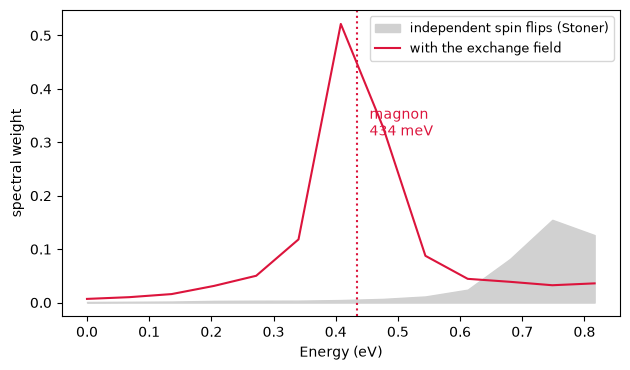

In [2]:
import matplotlib.pyplot as plt

edge = disp.susceptibilities[1]
ev = np.asarray(disp.frequencies) * 13.6057

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.fill_between(ev, edge.kohn_sham_spectral_function, color="0.82",
                label="independent spin flips (Stoner)")
ax.plot(ev, edge.spectral_function, color="crimson", label="with the exchange field")
ax.axvline(disp.energies_mev[1] / 1000, ls=":", color="crimson")
ax.text(disp.energies_mev[1] / 1000 + 0.02, 0.6 * edge.spectral_function.max(),
        "magnon\n%.0f meV" % disp.energies_mev[1], color="crimson")
ax.set(xlabel="Energy (eV)", ylabel="spectral weight")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()

The grey band is what the electrons would do if they ignored each other. The red peak
sits below it, and it is not a spin flip that happens to be cheap: it is a different
excitation, in which no electron changes its spin at all and the whole magnetization turns
together.

Nickel's measured spin-wave stiffness is about 550 meV Å$^2$, which would put a quadratic
magnon at 438 meV at this wavevector. The number above is the same size. That agreement
should not be pushed: the quadratic law is long past its range at $0.89$ Å$^{-1}$, and
resolving the small wavevectors where it does hold needs a much finer grid than the $4^3$
one used here, which is what makes a magnetic 3d metal expensive.

## When the mode goes soft

A magnon energy is positive only if the magnetic order it is a small oscillation *about* is
stable. Follow the enhancement across the zone and where it reaches one, the mode has
reached zero energy and is about to go through it: a spiral of that pitch is lower than the
ferromagnet, and the ferromagnet is not the ground state.

Nickel's enhancement falls away from $\mathbf q = 0$, which is what a stable ferromagnet
looks like. It is worth knowing that most simple models do not: a half-filled band on any
lattice prefers antiferromagnetic order, so a hydrogen crystal at any spacing comes out soft
at finite $\mathbf q$, and the calculation says so rather than producing a plausible
dispersion anyway.

In [3]:
for q, lam, w in zip(disp.qpoints, disp.enhancements, disp.energies_mev):
    print("q = (%.2f, %.2f, %.2f)   enhancement %.4f   %s"
          % (*q, lam,
             "soft: not the ground state" if lam > 1 else "magnon at %.0f meV" % w))

q = (0.00, 0.00, 0.00)   enhancement 1.0000   magnon at 0 meV
q = (0.00, 0.25, 0.25)   enhancement 0.6449   magnon at 434 meV


| | this calculation | reference |
|---|---|---|
| moment | 0.58 $\mu_B$ | 0.61 $\mu_B$ measured |
| Goldstone miss | 2.3% | 0 exactly |
| magnon at $0.89$ Å$^{-1}$ | 434 meV | cf. 438 meV, and see the caveat above |
| enhancement away from $\Gamma$ | falls | a stable ferromagnet |

The identities behind the error bar, and the convergence of both truncations, are in
`tests/regression/test_magnons.py` and `tests/unit/test_magnon_machinery.py`.
